In [5]:
import numpy as np

In [2]:
import h5py

archivo = r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video3_brillantina_oscura_PIV.mat"

with h5py.File(archivo, "r") as f:
    print(list(f.keys()))

['#refs#', '#subsystem#', 'Autolimit', 'CorrQuality_nr', 'FileName', 'PIVver', 'PathName', 'add_header', 'addfileinfo', 'algorithm_selection', 'alreadydisplayed', 'alreadydisplayed_warning_uncertainty', 'autoscale_vec', 'batchModeActive', 'bg_img_A', 'bg_img_B', 'bg_mode', 'bright_filter_thresh', 'calib_boardtype', 'calib_checkersize', 'calib_columns', 'calib_dolivedetect', 'calib_markersize', 'calib_origincolor', 'calib_rows', 'calib_upscale', 'calib_use_tilted_model', 'calib_usecalibration', 'calib_userectification', 'calib_viewtype', 'calu', 'calv', 'calxy', 'cam_K_opencv', 'cam_tilted_D', 'cam_use_calibration', 'cam_use_rectification', 'cam_use_tilted_model', 'cameraParams', 'cancel', 'clahe_enable', 'clahe_size', 'colormap_choice', 'colormap_interpolation', 'colormap_steps', 'contrast_filter_thresh', 'corr_filter_thresh', 'darkmode', 'delimiter', 'deriv_color_idx', 'derived', 'displacement_only', 'displaywhat', 'do_bright_filter', 'do_contrast_filter', 'do_corr2_filter', 'enable_h

In [3]:
import h5py

archivo = r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video3_brillantina_oscura_PIV.mat"

with h5py.File(archivo, "r") as f:

    nombres = [
        "resultslist",
        "calxy",
        "calu",
        "calv",
        "roirect",
        "masks_in_frame",
        "time_inp_string",
        "realdist_string"
    ]

    for nombre in nombres:

        obj = f[nombre]

        print("\n", nombre)
        print("tipo:", type(obj))
        print("shape:", getattr(obj, "shape", None))
        print("dtype:", getattr(obj, "dtype", None))


 resultslist
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (663, 15)
dtype: object

 calxy
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (1, 1)
dtype: float64

 calu
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (1, 1)
dtype: float64

 calv
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (1, 1)
dtype: float64

 roirect
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (4, 1)
dtype: float64

 masks_in_frame
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (663, 1)
dtype: object

 time_inp_string
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (6, 1)
dtype: uint16

 realdist_string
tipo: <class 'h5py._hl.dataset.Dataset'>
shape: (4, 1)
dtype: uint16


In [6]:
with h5py.File(archivo, "r") as f:

    resultados = f["resultslist"]

    print("Shape resultslist:", resultados.shape)

    for indice in np.ndindex(resultados.shape):

        referencia = resultados[indice]

        if referencia:

            objeto = f[referencia]

            print(
                indice,
                "->",
                objeto.name,
                "shape:",
                objeto.shape,
                "dtype:",
                objeto.dtype
            )

        if indice[0] > 3:
            break

Shape resultslist: (663, 15)
(0, 0) -> /#refs#/XQ shape: (31, 30) dtype: float32
(0, 1) -> /#refs#/YQ shape: (31, 30) dtype: float32
(0, 2) -> /#refs#/ZQ shape: (31, 30) dtype: float32
(0, 3) -> /#refs#/1Q shape: (31, 30) dtype: float32
(0, 4) -> /#refs#/2Q shape: (31, 30) dtype: float32
(0, 5) -> /#refs#/3Q shape: (2,) dtype: uint64
(0, 6) -> /#refs#/4Q shape: (31, 30) dtype: float32
(0, 7) -> /#refs#/5Q shape: (31, 30) dtype: float32
(0, 8) -> /#refs#/6Q shape: (31, 30) dtype: float32
(0, 9) -> /#refs#/7Q shape: (2,) dtype: uint64
(0, 10) -> /#refs#/8Q shape: (2,) dtype: uint64
(0, 11) -> /#refs#/9Q shape: (31, 30) dtype: float32
(0, 12) -> /#refs#/0Q shape: (31, 30) dtype: float32
(0, 13) -> /#refs#/aR shape: (31, 30) dtype: float32
(0, 14) -> /#refs#/bR shape: (2,) dtype: uint64
(1, 0) -> /#refs#/cR shape: (31, 30) dtype: float32
(1, 1) -> /#refs#/dR shape: (31, 30) dtype: float32
(1, 2) -> /#refs#/eR shape: (31, 30) dtype: float32
(1, 3) -> /#refs#/fR shape: (31, 30) dtype: float3

In [7]:
archivo = r"C:\Users\user\Desktop\Labo5\1_Fluidos\analisis\G\video3_brillantina_oscura_PIV.mat"


def leer_celda(f, resultslist, frame, columna):
    ref = resultslist[frame, columna]
    return np.array(f[ref])


with h5py.File(archivo, "r") as f:

    results = f["resultslist"]

    # Frame PIV número 0
    x = leer_celda(f, results, 0, 0)
    y = leer_celda(f, results, 0, 1)

    # Campo crudo
    u_raw = leer_celda(f, results, 0, 2)
    v_raw = leer_celda(f, results, 0, 3)

    # Campo DESPUÉS de validación/interpolación
    u = leer_celda(f, results, 0, 6)
    v = leer_celda(f, results, 0, 7)

    tipo = leer_celda(f, results, 0, 8)


print("x:", x.shape)
print("y:", y.shape)
print("u:", u.shape)
print("v:", v.shape)
print("tipo:", tipo.shape)

x: (31, 30)
y: (31, 30)
u: (31, 30)
v: (31, 30)
tipo: (31, 30)


In [8]:
print("x primera fila:", x[0, :5])
print("x primera columna:", x[:5, 0])

print()

print("y primera fila:", y[0, :5])
print("y primera columna:", y[:5, 0])

x primera fila: [242. 242. 242. 242. 242.]
x primera columna: [242. 267. 292. 317. 342.]

y primera fila: [590. 615. 640. 665. 690.]
y primera columna: [590. 590. 590. 590. 590.]


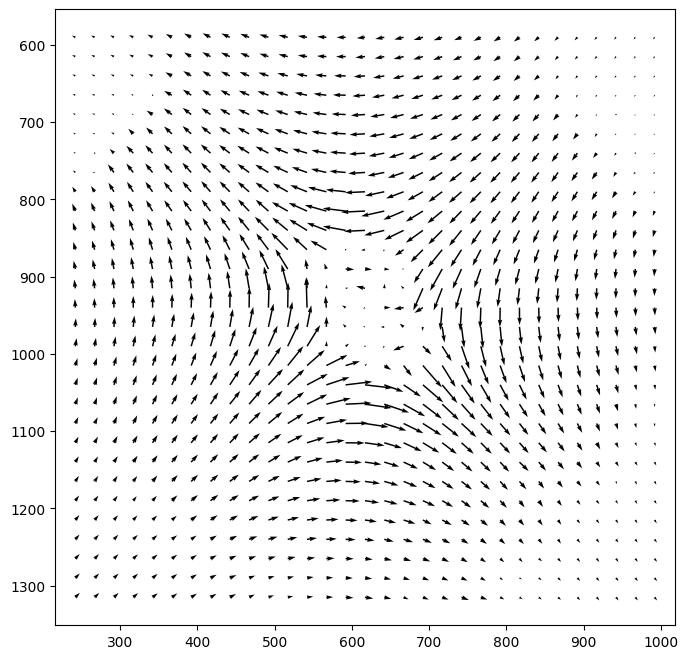

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.quiver(
    x,
    y,
    u,
    v
)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.show()

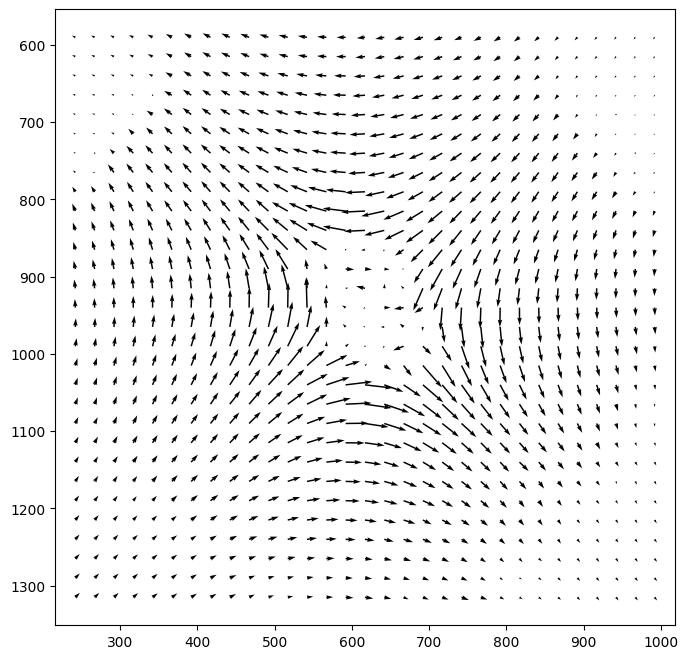

In [10]:
plt.figure(figsize=(8, 8))

plt.quiver(
    x.T,
    y.T,
    u.T,
    v.T
)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.show()

In [11]:
with h5py.File(archivo, "r") as f:

    calu = float(f["calu"][0, 0])
    calv = float(f["calv"][0, 0])
    calxy = float(f["calxy"][0, 0])

print("calu =", calu)
print("calv =", calv)
print("calxy =", calxy)

calu = nan
calv = nan
calxy = nan


In [12]:
print("u min/max:", np.nanmin(u), np.nanmax(u))
print("v min/max:", np.nanmin(v), np.nanmax(v))

u min/max: -14.4013195 16.70312
v min/max: -14.038079 18.077509


In [13]:
print("x primera fila:")
print(x[0, :10])

print("\nx primera columna:")
print(x[:10, 0])

print("\ny primera fila:")
print(y[0, :10])

print("\ny primera columna:")
print(y[:10, 0])

x primera fila:
[242. 242. 242. 242. 242. 242. 242. 242. 242. 242.]

x primera columna:
[242. 267. 292. 317. 342. 367. 392. 417. 442. 467.]

y primera fila:
[590. 615. 640. 665. 690. 715. 740. 765. 790. 815.]

y primera columna:
[590. 590. 590. 590. 590. 590. 590. 590. 590. 590.]


In [14]:
x_plot = x.T
y_plot = y.T

u_plot = u.T
v_plot = v.T

print(x_plot[0, :10])
print(y_plot[:10, 0])

[242. 267. 292. 317. 342. 367. 392. 417. 442. 467.]
[590. 615. 640. 665. 690. 715. 740. 765. 790. 815.]


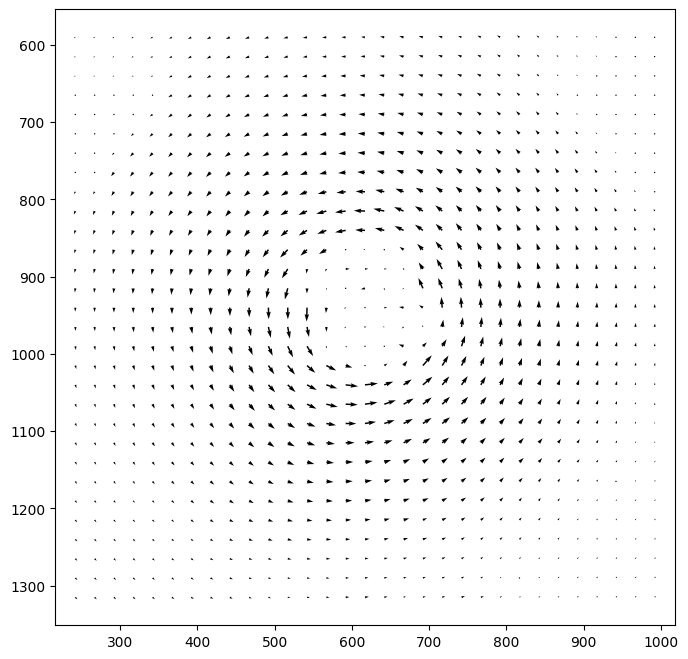

In [15]:
plt.figure(figsize=(8, 8))

plt.quiver(
    x_plot,
    y_plot,
    u_plot,
    v_plot,
    angles="xy",
    scale_units="xy",
    scale=1
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.show()